In [1]:
import importlib
import gymnasium as gym

import env.afm_env
importlib.reload(env.afm_env)
from env.afm_env import AfmEnvironment
from matplotlib import pyplot as plt

# env = AfmEnvironment(
#     surface_configs=[{'data_file_path': 'environments/pt_111_small_rows_missing.npz'}],
#     num_historic_data=30,
#     num_actions=1,
# )

def test_afm_environment(
    surface_path: str = "materials/pt_111_small_rows_missing.xyz",
    params_path: str = "materials/params_code.ini",
    num_historic_data: int = 30,
    num_actions: int = 1,
    seed: int = 123,
    angle_deg: float = 0.0,
    tx: float = 0.0,
    ty: float = 0.0,
    show_plot: bool = True
) -> AfmEnvironment:
    # Create environment with specified parameters using the new surface_configs API
    env = AfmEnvironment(
        surface_configs=[
            {
                'surface_path': surface_path,
                'params_path': params_path,
                'scan_params': [{'angle_deg': angle_deg, 'tx': tx, 'ty': ty}],
            }
        ],
        num_historic_data=num_historic_data,
        num_actions=num_actions,
    )

    # Reset environment and perform initial steps
    env.reset(seed=seed)
    env.step([0])
    env.step([0])
    env.step([0])
    env.step([0])
    env.step([0])

    # Scan through all positions at current height
    for _ in range(env._x_lim * env._y_lim):
        env.step([100])

    # Display the generated image
    if show_plot:
        plt.figure(figsize=(8, 8))
        plt.imshow(env.generated_image.T)
        plt.colorbar()
        plt.title(f"AFM Image (angle={angle_deg} deg, tx={tx}, ty={ty})")
        plt.show()

    return env

 PACKAGE_PATH =  /home/henry/miniforge3/envs/IProject/lib/python3.11/site-packages/ppafm
 CPP_PATH     =  /home/henry/miniforge3/envs/IProject/lib/python3.11/site-packages/ppafm/cpp


In [4]:
surface_path = "materials/pt_111_small_rows_missing.xyz"
params_path = "materials/params_code.ini"
num_historic_data = 30
num_actions = 1
angles = [0]  #, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180]
txs = [0]  #, 7, 13, 20]
tys = [0]  #, 7, 13, 20]

scan_params = []
for angle_deg in angles:
    for tx in txs:
        for ty in tys:
            scan_params.append({'angle_deg': angle_deg, 'tx': tx, 'ty': ty})

env = AfmEnvironment(
    surface_configs=[
        {
            'surface_path': surface_path,
            'params_path': params_path,
            'scan_params': scan_params,
        }
    ],
    num_historic_data=num_historic_data,
    num_actions=num_actions,
 )

env.save_to_file("environments_test/pt_111_small_rows_missing")

Initializing an OpenCL environment on NVIDIA CUDA
Applying PBC True
Applying nPBC [3, 3, 0]
Applying gridN [277, 277, 91]
Applying gridO [0.0, 0.0, 0.0]
Applying gridA [27.71858582251266, 0.0, 0.0]
Applying gridB [13.85929291125633, 24.004999479275142, 0.0]
Applying gridC [0.0, 0.0, 9.052852220893334]
Applying FFgrid0 [-1.0, -1.0, -1.0]
Applying FFgridA [-1.0, -1.0, -1.0]
Applying FFgridB [-1.0, -1.0, -1.0]
Applying FFgridC [-1.0, -1.0, -1.0]
Applying moleculeShift [0.0, 0.0, 0.0]
Applying probeType 8
Applying charge 0.0
Applying Apauli 18.0
Applying Bpauli 1.0
Applying ffModel LJ
Applying Rcore 0.7
Applying r0Probe [0.0, 0.0, 3.0]
Applying stiffness [0.24, 0.24, 20.0]
Applying klat 0.5
Applying krad 20.0
Applying tip s
Applying sigma 0.7
Applying scanStep [0.2, 0.2, 0.01]
Applying scanMin [0.0, 0.0, 14.0]
Applying scanMax [40.0, 40.0, 23.0]
Applying scanTilt [0.0, 0.0, -0.1]
Applying tiltedScan False
Applying kCantilever 1800.0
Applying f0Cantilever 30300.0
Applying Amplitude 1.0
Appl

/home/henry/miniforge3/envs/IProject/lib/python3.11/site-packages/ppafm/ocl/field.py:641: RepeatedKernelRetrieval: Kernel 'interp_tip_at' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  cl_program.interp_tip_at(queue, global_size, local_size,


In [ ]:
env.save_to_file("environments/pt_111_small_rows_missing")

Initializing an OpenCL environment on NVIDIA CUDA
Applying PBC True
Applying nPBC [3, 3, 0]
Applying gridN [277, 277, 91]
Applying gridO [0.0, 0.0, 0.0]
Applying gridA [27.71858582251266, 0.0, 0.0]
Applying gridB [13.85929291125633, 24.004999479275142, 0.0]
Applying gridC [0.0, 0.0, 9.052852220893334]
Applying FFgrid0 [-1.0, -1.0, -1.0]
Applying FFgridA [-1.0, -1.0, -1.0]
Applying FFgridB [-1.0, -1.0, -1.0]
Applying FFgridC [-1.0, -1.0, -1.0]
Applying moleculeShift [0.0, 0.0, 0.0]
Applying probeType 8
Applying charge 0.0
Applying Apauli 18.0
Applying Bpauli 1.0
Applying ffModel LJ
Applying Rcore 0.7
Applying r0Probe [0.0, 0.0, 3.0]
Applying stiffness [0.24, 0.24, 20.0]
Applying klat 0.5
Applying krad 20.0
Applying tip s
Applying sigma 0.7
Applying scanStep [0.2, 0.2, 0.01]
Applying scanMin [0.0, 0.0, 14.0]
Applying scanMax [40.0, 40.0, 23.0]
Applying scanTilt [0.0, 0.0, -0.1]
Applying tiltedScan False
Applying kCantilever 1800.0
Applying f0Cantilever 30300.0
Applying Amplitude 1.0
Appl

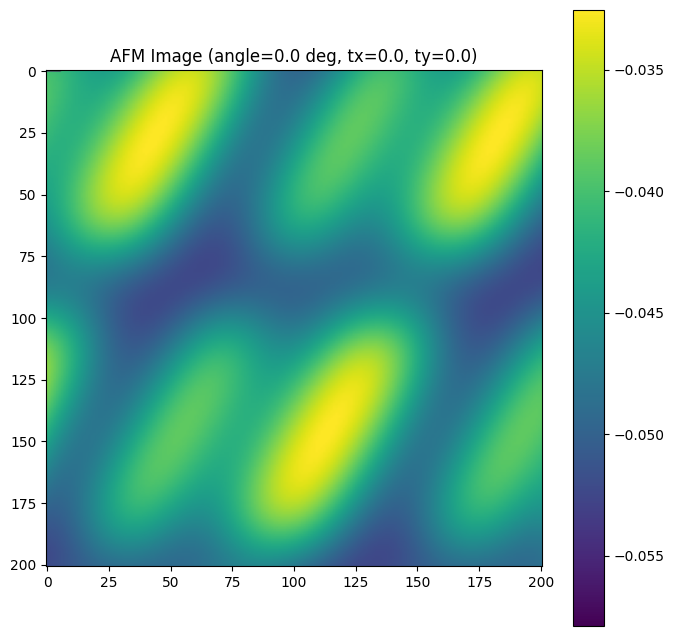

Initializing an OpenCL environment on NVIDIA CUDA
Applying PBC True
Applying nPBC [3, 3, 0]
Applying gridN [277, 277, 91]
Applying gridO [0.0, 0.0, 0.0]
Applying gridA [27.71858582251266, 0.0, 0.0]
Applying gridB [13.85929291125633, 24.004999479275142, 0.0]
Applying gridC [0.0, 0.0, 9.052852220893334]
Applying FFgrid0 [-1.0, -1.0, -1.0]
Applying FFgridA [-1.0, -1.0, -1.0]
Applying FFgridB [-1.0, -1.0, -1.0]
Applying FFgridC [-1.0, -1.0, -1.0]
Applying moleculeShift [0.0, 0.0, 0.0]
Applying probeType 8
Applying charge 0.0
Applying Apauli 18.0
Applying Bpauli 1.0
Applying ffModel LJ
Applying Rcore 0.7
Applying r0Probe [0.0, 0.0, 3.0]
Applying stiffness [0.24, 0.24, 20.0]
Applying klat 0.5
Applying krad 20.0
Applying tip s
Applying sigma 0.7
Applying scanStep [0.2, 0.2, 0.01]
Applying scanMin [0.0, 0.0, 14.0]
Applying scanMax [40.0, 40.0, 23.0]
Applying scanTilt [0.0, 0.0, -0.1]
Applying tiltedScan False
Applying kCantilever 1800.0
Applying f0Cantilever 30300.0
Applying Amplitude 1.0
Appl

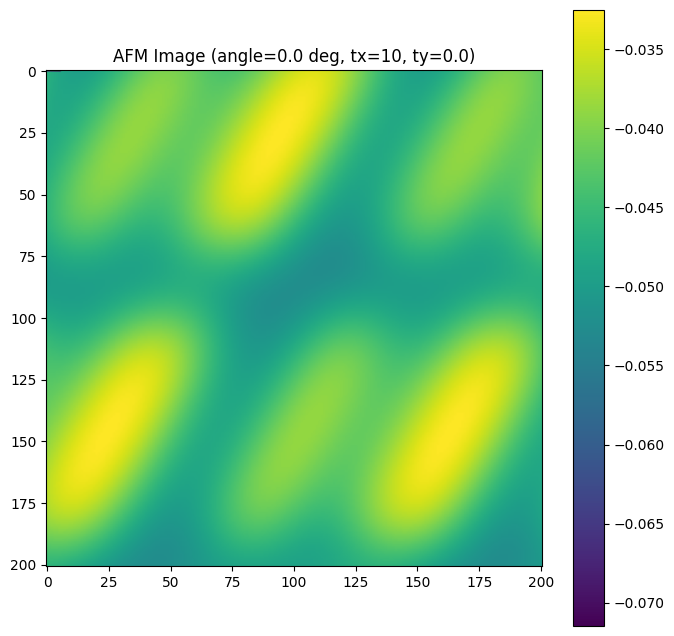

Initializing an OpenCL environment on NVIDIA CUDA
Applying PBC True
Applying nPBC [3, 3, 0]
Applying gridN [277, 277, 91]
Applying gridO [0.0, 0.0, 0.0]
Applying gridA [27.71858582251266, 0.0, 0.0]
Applying gridB [13.85929291125633, 24.004999479275142, 0.0]
Applying gridC [0.0, 0.0, 9.052852220893334]
Applying FFgrid0 [-1.0, -1.0, -1.0]
Applying FFgridA [-1.0, -1.0, -1.0]
Applying FFgridB [-1.0, -1.0, -1.0]
Applying FFgridC [-1.0, -1.0, -1.0]
Applying moleculeShift [0.0, 0.0, 0.0]
Applying probeType 8
Applying charge 0.0
Applying Apauli 18.0
Applying Bpauli 1.0
Applying ffModel LJ
Applying Rcore 0.7
Applying r0Probe [0.0, 0.0, 3.0]
Applying stiffness [0.24, 0.24, 20.0]
Applying klat 0.5
Applying krad 20.0
Applying tip s
Applying sigma 0.7
Applying scanStep [0.2, 0.2, 0.01]
Applying scanMin [0.0, 0.0, 14.0]
Applying scanMax [40.0, 40.0, 23.0]
Applying scanTilt [0.0, 0.0, -0.1]
Applying tiltedScan False
Applying kCantilever 1800.0
Applying f0Cantilever 30300.0
Applying Amplitude 1.0
Appl

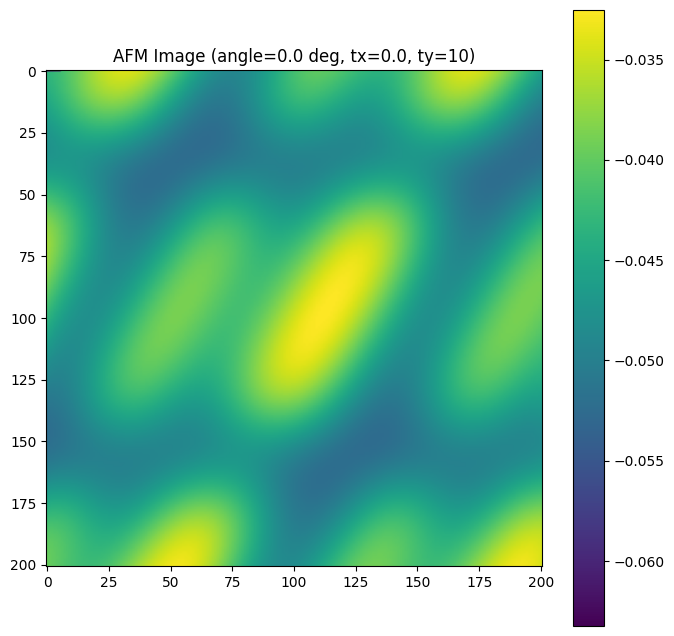

Initializing an OpenCL environment on NVIDIA CUDA
Applying PBC True
Applying nPBC [3, 3, 0]
Applying gridN [277, 277, 91]
Applying gridO [0.0, 0.0, 0.0]
Applying gridA [24.004999479275146, 13.859292911256329, 0.0]
Applying gridB [3.701474106889442e-15, 27.71858582251266, 0.0]
Applying gridC [0.0, 0.0, 9.052852220893334]
Applying FFgrid0 [-1.0, -1.0, -1.0]
Applying FFgridA [-1.0, -1.0, -1.0]
Applying FFgridB [-1.0, -1.0, -1.0]
Applying FFgridC [-1.0, -1.0, -1.0]
Applying moleculeShift [0.0, 0.0, 0.0]
Applying probeType 8
Applying charge 0.0
Applying Apauli 18.0
Applying Bpauli 1.0
Applying ffModel LJ
Applying Rcore 0.7
Applying r0Probe [0.0, 0.0, 3.0]
Applying stiffness [0.24, 0.24, 20.0]
Applying klat 0.5
Applying krad 20.0
Applying tip s
Applying sigma 0.7
Applying scanStep [0.2, 0.2, 0.01]
Applying scanMin [0.0, 0.0, 14.0]
Applying scanMax [40.0, 40.0, 23.0]
Applying scanTilt [0.0, 0.0, -0.1]
Applying tiltedScan False
Applying kCantilever 1800.0
Applying f0Cantilever 30300.0
Applying

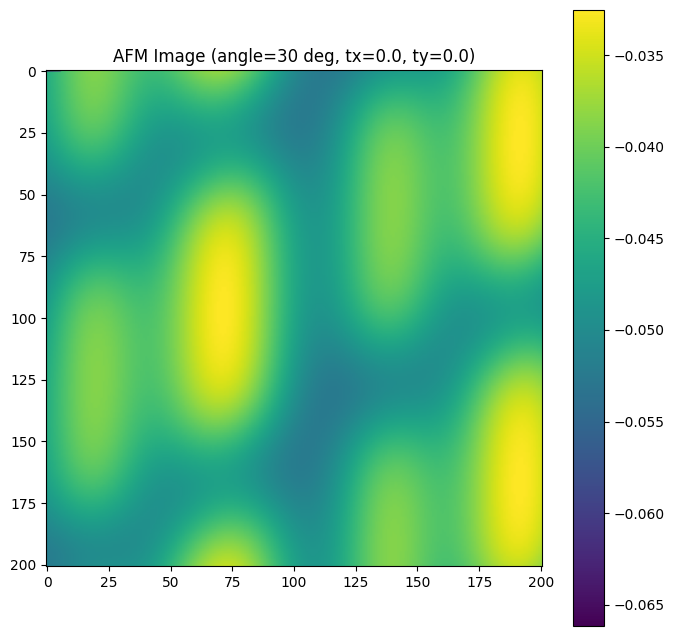

Initializing an OpenCL environment on NVIDIA CUDA
Applying PBC True
Applying nPBC [3, 3, 0]
Applying gridN [277, 277, 91]
Applying gridO [0.0, 0.0, 0.0]
Applying gridA [24.004999479275146, 13.859292911256329, 0.0]
Applying gridB [3.701474106889442e-15, 27.71858582251266, 0.0]
Applying gridC [0.0, 0.0, 9.052852220893334]
Applying FFgrid0 [-1.0, -1.0, -1.0]
Applying FFgridA [-1.0, -1.0, -1.0]
Applying FFgridB [-1.0, -1.0, -1.0]
Applying FFgridC [-1.0, -1.0, -1.0]
Applying moleculeShift [0.0, 0.0, 0.0]
Applying probeType 8
Applying charge 0.0
Applying Apauli 18.0
Applying Bpauli 1.0
Applying ffModel LJ
Applying Rcore 0.7
Applying r0Probe [0.0, 0.0, 3.0]
Applying stiffness [0.24, 0.24, 20.0]
Applying klat 0.5
Applying krad 20.0
Applying tip s
Applying sigma 0.7
Applying scanStep [0.2, 0.2, 0.01]
Applying scanMin [0.0, 0.0, 14.0]
Applying scanMax [40.0, 40.0, 23.0]
Applying scanTilt [0.0, 0.0, -0.1]
Applying tiltedScan False
Applying kCantilever 1800.0
Applying f0Cantilever 30300.0
Applying

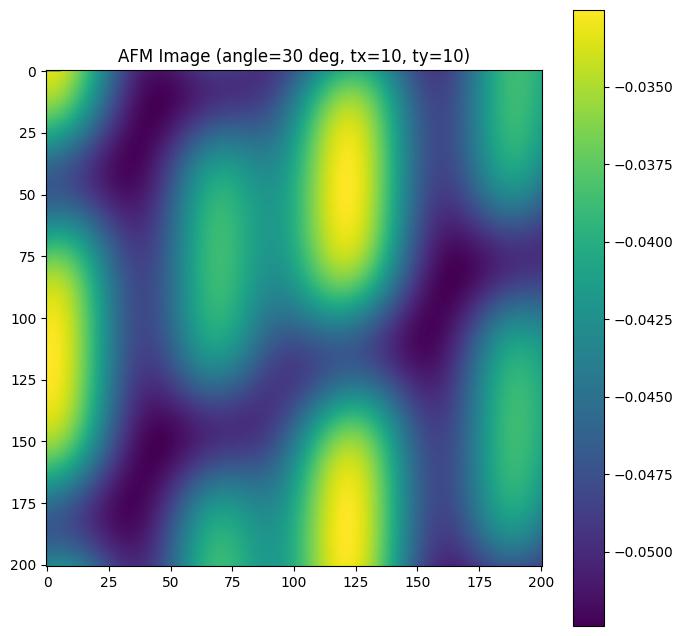

In [5]:
test_afm_environment()
test_afm_environment(tx=10)
test_afm_environment(ty=10)
test_afm_environment(angle_deg=30)
test_afm_environment(tx=10, ty=10, angle_deg=30)

Initializing an OpenCL environment on NVIDIA CUDA
Applying PBC True
Applying nPBC [3, 3, 0]
Applying gridN [277, 277, 91]
Applying gridO [0.0, 0.0, 0.0]
Applying gridA [27.71858582251266, 0.0, 0.0]
Applying gridB [13.85929291125633, 24.004999479275142, 0.0]
Applying gridC [0.0, 0.0, 9.052852220893334]
Applying FFgrid0 [-1.0, -1.0, -1.0]
Applying FFgridA [-1.0, -1.0, -1.0]
Applying FFgridB [-1.0, -1.0, -1.0]
Applying FFgridC [-1.0, -1.0, -1.0]
Applying moleculeShift [0.0, 0.0, 0.0]
Applying probeType 8
Applying charge 0.0
Applying Apauli 18.0
Applying Bpauli 1.0
Applying ffModel LJ
Applying Rcore 0.7
Applying r0Probe [0.0, 0.0, 3.0]
Applying stiffness [0.24, 0.24, 20.0]
Applying klat 0.5
Applying krad 20.0
Applying tip s
Applying sigma 0.7
Applying scanStep [0.2, 0.2, 0.01]
Applying scanMin [0.0, 0.0, 14.0]
Applying scanMax [40.0, 40.0, 23.0]
Applying scanTilt [0.0, 0.0, -0.1]
Applying tiltedScan False
Applying kCantilever 1800.0
Applying f0Cantilever 30300.0
Applying Amplitude 1.0
Appl

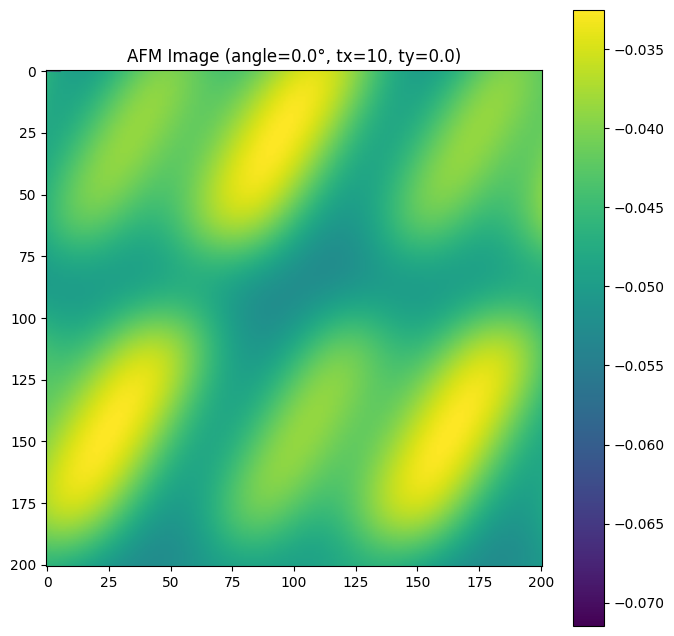

Initializing an OpenCL environment on NVIDIA CUDA
Applying PBC True
Applying nPBC [3, 3, 0]
Applying gridN [277, 277, 91]
Applying gridO [0.0, 0.0, 0.0]
Applying gridA [27.71858582251266, 0.0, 0.0]
Applying gridB [13.85929291125633, 24.004999479275142, 0.0]
Applying gridC [0.0, 0.0, 9.052852220893334]
Applying FFgrid0 [-1.0, -1.0, -1.0]
Applying FFgridA [-1.0, -1.0, -1.0]
Applying FFgridB [-1.0, -1.0, -1.0]
Applying FFgridC [-1.0, -1.0, -1.0]
Applying moleculeShift [0.0, 0.0, 0.0]
Applying probeType 8
Applying charge 0.0
Applying Apauli 18.0
Applying Bpauli 1.0
Applying ffModel LJ
Applying Rcore 0.7
Applying r0Probe [0.0, 0.0, 3.0]
Applying stiffness [0.24, 0.24, 20.0]
Applying klat 0.5
Applying krad 20.0
Applying tip s
Applying sigma 0.7
Applying scanStep [0.2, 0.2, 0.01]
Applying scanMin [0.0, 0.0, 14.0]
Applying scanMax [40.0, 40.0, 23.0]
Applying scanTilt [0.0, 0.0, -0.1]
Applying tiltedScan False
Applying kCantilever 1800.0
Applying f0Cantilever 30300.0
Applying Amplitude 1.0
Appl

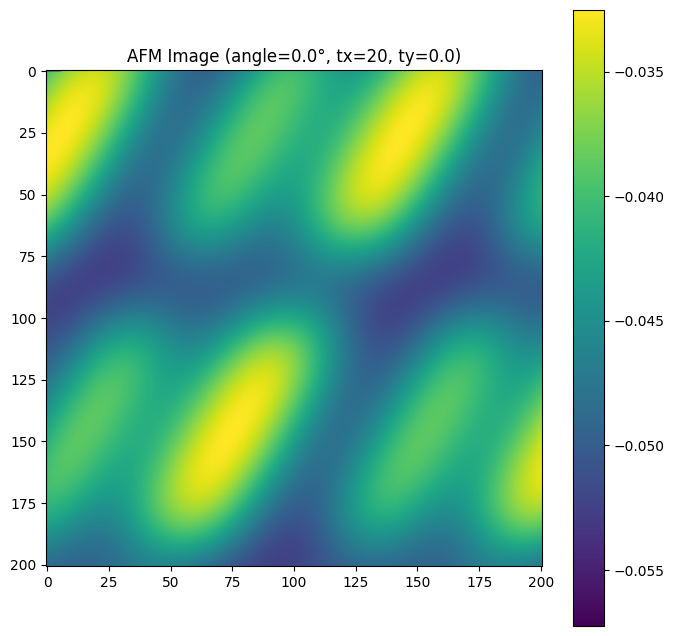

Initializing an OpenCL environment on NVIDIA CUDA
Applying PBC True
Applying nPBC [3, 3, 0]
Applying gridN [277, 277, 91]
Applying gridO [0.0, 0.0, 0.0]
Applying gridA [27.71858582251266, 0.0, 0.0]
Applying gridB [13.85929291125633, 24.004999479275142, 0.0]
Applying gridC [0.0, 0.0, 9.052852220893334]
Applying FFgrid0 [-1.0, -1.0, -1.0]
Applying FFgridA [-1.0, -1.0, -1.0]
Applying FFgridB [-1.0, -1.0, -1.0]
Applying FFgridC [-1.0, -1.0, -1.0]
Applying moleculeShift [0.0, 0.0, 0.0]
Applying probeType 8
Applying charge 0.0
Applying Apauli 18.0
Applying Bpauli 1.0
Applying ffModel LJ
Applying Rcore 0.7
Applying r0Probe [0.0, 0.0, 3.0]
Applying stiffness [0.24, 0.24, 20.0]
Applying klat 0.5
Applying krad 20.0
Applying tip s
Applying sigma 0.7
Applying scanStep [0.2, 0.2, 0.01]
Applying scanMin [0.0, 0.0, 14.0]
Applying scanMax [40.0, 40.0, 23.0]
Applying scanTilt [0.0, 0.0, -0.1]
Applying tiltedScan False
Applying kCantilever 1800.0
Applying f0Cantilever 30300.0
Applying Amplitude 1.0
Appl

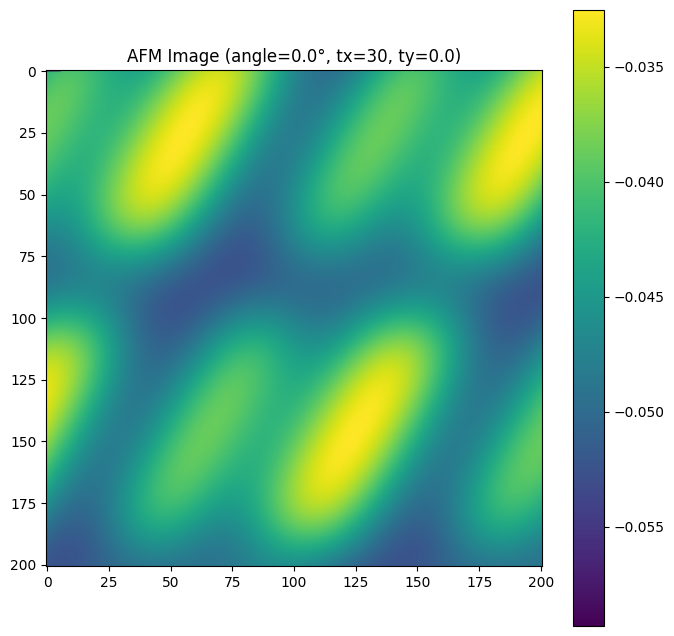

In [22]:
test_afm_environment(tx=10)
test_afm_environment(tx=20)
test_afm_environment(tx=30)

In [2]:
ENVIRONMENT_DIRS = [
    # "environments/pt_111_1a",
    # "environments/pt_111_2v",
    "environments/pt_111_2v_1a",
    # "environments/pt_111_3v_1a",
]

# Easy tuning knobs for optimal-height calculation
SIGMA = 2
HEIGHT_OFFSET = 0.4

env = AfmEnvironment(
    surface_configs=[
        {"data_dir_path": env_dir} for env_dir in ENVIRONMENT_DIRS
    ],
    num_historic_data=40,
    num_actions=1,
    df_scale=10,
    dz_scale=10,
    sigma=SIGMA,
    height_offset_reward=HEIGHT_OFFSET,
)

print(f"Using sigma={SIGMA}, height_offset={HEIGHT_OFFSET}")

Using sigma=2, height_offset=0.4


{'x': array([-0.96, -0.97, -0.98, -0.99, -1.  , -1.  , -1.  , -1.  , -1.  ,
       -1.  , -1.  , -1.  , -1.  , -1.  , -1.  , -1.  , -1.  , -1.  ,
       -1.  , -1.  , -1.  , -1.  , -1.  , -1.  , -1.  , -1.  , -1.  ,
       -1.  , -1.  , -1.  , -1.  , -1.  , -1.  , -1.  , -1.  , -1.  ,
       -1.  , -1.  , -1.  , -1.  ], dtype=float32), 'y': array([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1.], dtype=float32), 'dz': array([0.04, 0.03, 0.02, 0.01, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ], dtype=float32), 'df': array([-0.00526428, -0.00560303, -0.00596619, -0.00635376, -0.0067688 ,
       -0.0067688 , -0.0067688 , -0.0067688

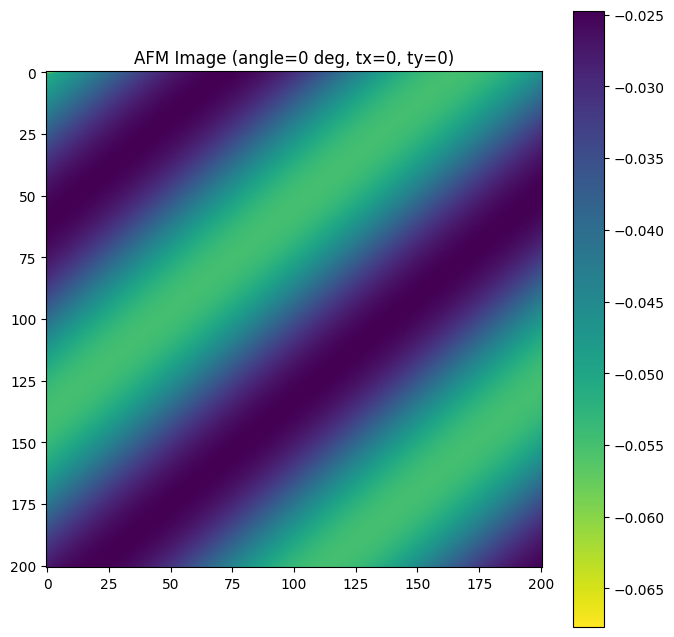

In [194]:
env.reset()#seed=42)
# env.step([0])
# env.step([0])
# env.step([0])
# env.step([0])
z_start = env._get_info()["z"]
env.step([0.1])
env.step([0.1])
env.step([0.1])
env.step([0.1])
print(env._get_obs())

for _ in range(env._x_lim * env._y_lim):
    env.step([100])

plt.figure(figsize=(8, 8))
plt.imshow(env.generated_image.T, cmap="viridis_r")
plt.colorbar()
plt.title(f"AFM Image (angle={angle_deg} deg, tx={tx}, ty={ty})")
plt.show()

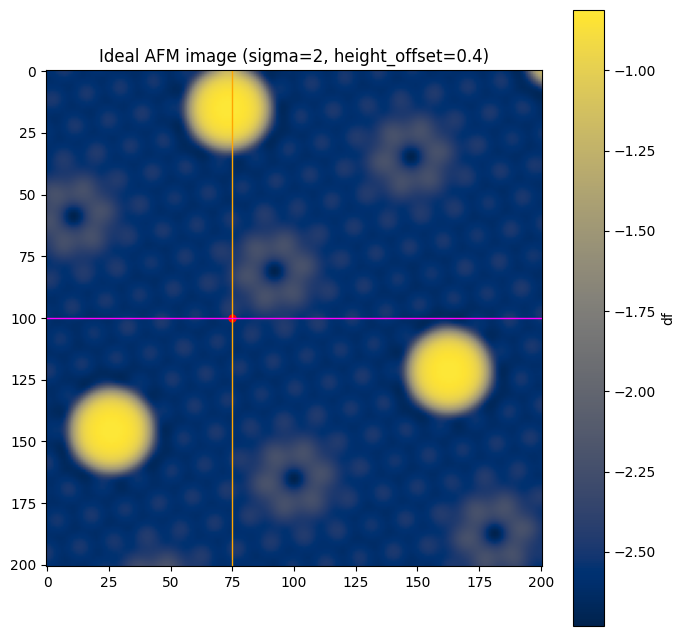

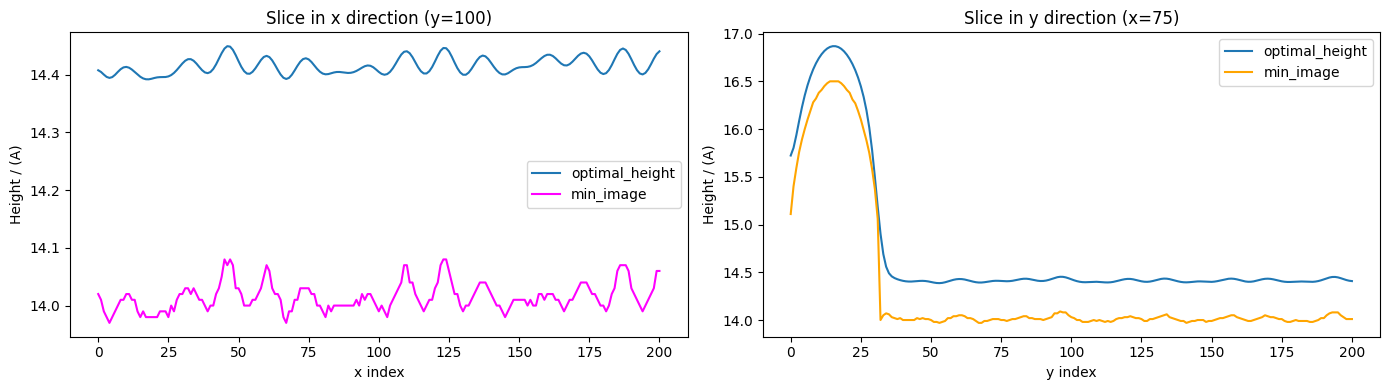

In [20]:
import numpy as np

env.reset()

# Ideal image if the tip follows optimal_height exactly at every (x, y)
z_axis = env.z_height_map.astype(float)

def interp_df_at_z(profile, z_values, z_target):
    # np.interp requires ascending x-values
    if z_values[0] > z_values[-1]:
        return np.interp(z_target, z_values[::-1], profile[::-1])
    return np.interp(z_target, z_values, profile)

ideal_image = np.empty((env._x_lim, env._y_lim), dtype=np.float64)
for x in range(env._x_lim):
    for y in range(env._y_lim):
        ideal_image[x, y] = interp_df_at_z(
            env.afm_images[x, y, :].astype(float),
            z_axis,
            float(env.optimal_height[x, y]),
        )

# Slice coordinate used for both overlay and 1D slice plots
xy = (75, 100)  # (env._x_lim // 2, env._y_lim // 2)

plt.figure(figsize=(8, 8))
plt.imshow(ideal_image.T, cmap="cividis")
plt.colorbar(label="df")
plt.scatter(xy[0], xy[1], color="red", s=25)
plt.axvline(xy[0], color="orange", linewidth=1)
plt.axhline(xy[1], color="magenta", linewidth=1)
plt.title(
    f"Ideal AFM image (sigma={env.sigma}, height_offset={env.height_offset_reward})"
)
plt.show()

# 1D slices of height maps, matching reward_investigation style
plt.subplots(1, 2, figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.title(f"Slice in x direction (y={xy[1]})")
plt.plot(env.optimal_height[:, xy[1]], label="optimal_height")
plt.plot(env.min_image[:, xy[1]], color="magenta", label="min_image")
plt.ylabel("Height / (A)")
plt.xlabel("x index")
plt.legend()

plt.subplot(1, 2, 2)
plt.title(f"Slice in y direction (x={xy[0]})")
plt.plot(env.optimal_height[xy[0], :], label="optimal_height")
plt.plot(env.min_image[xy[0], :], color="orange", label="min_image")
plt.ylabel("Height / (A)")
plt.xlabel("y index")
plt.legend()

plt.tight_layout()
plt.show()

Initializing an OpenCL environment on NVIDIA CUDA
Applying PBC True
Applying nPBC [3, 3, 0]
Applying gridN [277, 277, 91]
Applying gridO [0.0, 0.0, 0.0]
Applying gridA [27.71858582251266, 0.0, 0.0]
Applying gridB [13.85929291125633, 24.004999479275142, 0.0]
Applying gridC [0.0, 0.0, 9.052852220893334]
Applying FFgrid0 [-1.0, -1.0, -1.0]
Applying FFgridA [-1.0, -1.0, -1.0]
Applying FFgridB [-1.0, -1.0, -1.0]
Applying FFgridC [-1.0, -1.0, -1.0]
Applying moleculeShift [0.0, 0.0, 0.0]
Applying probeType 8
Applying charge 0.0
Applying Apauli 18.0
Applying Bpauli 1.0
Applying ffModel LJ
Applying Rcore 0.7
Applying r0Probe [0.0, 0.0, 3.0]
Applying stiffness [0.24, 0.24, 20.0]
Applying klat 0.5
Applying krad 20.0
Applying tip s
Applying sigma 0.7
Applying scanStep [0.2, 0.2, 0.01]
Applying scanMin [0.0, 0.0, 12.0]
Applying scanMax [40.0, 40.0, 23.0]
Applying scanTilt [0.0, 0.0, -0.1]
Applying tiltedScan False
Applying kCantilever 1800.0
Applying f0Cantilever 30300.0
Applying Amplitude 1.0
Appl

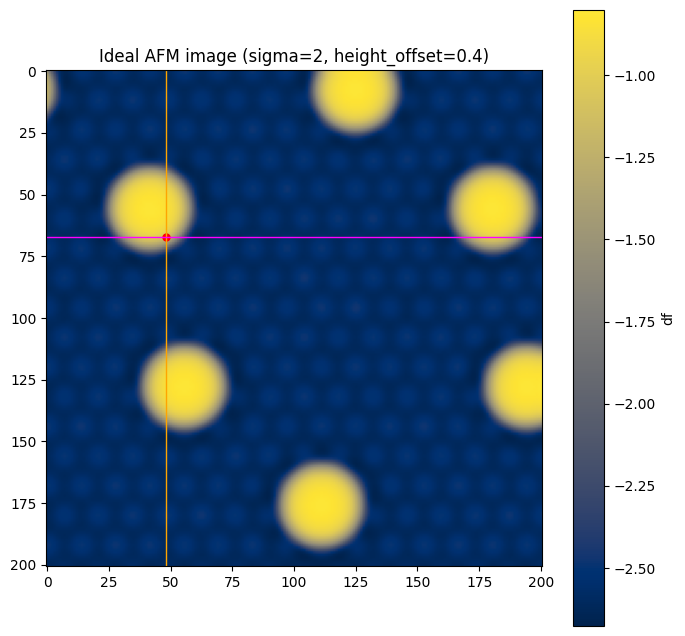

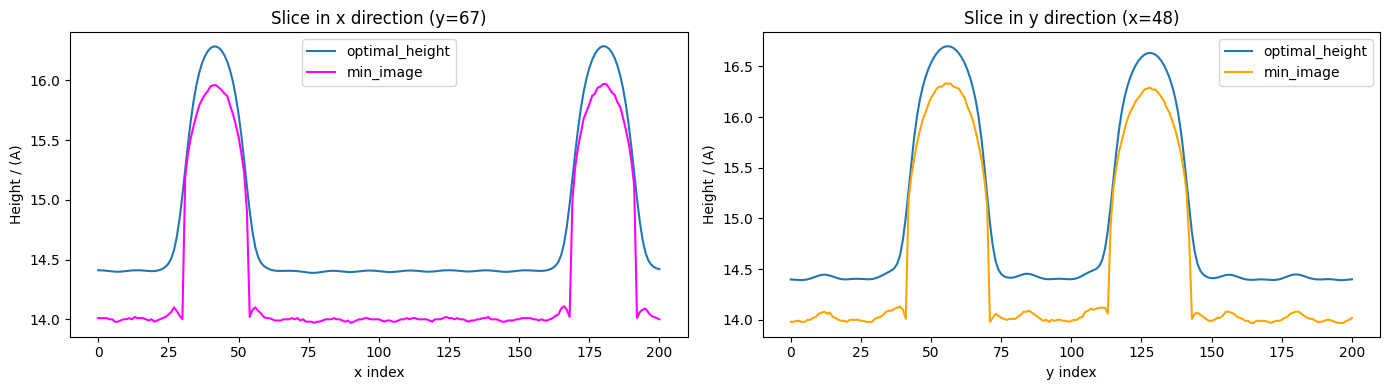

In [57]:
import numpy as np

# Compute AFM images on the fly directly from .xyz files (no pre-generated env folders)
XYZ_FILES = [
    # "materials/final_files/pt_111_3holes_2adatoms.xyz",
    # "materials/final_files/pt_111_3holes_1adatoms.xyz",
    # "materials/final_files/pt_111_2v_1a.xyz",
    "materials/final_files/pt_111_2adatoms.xyz",
    # "materials/final_files/pt_111_1adatom.xyz",
    # "materials/final_files/pt_111_4holes.xyz",
    # "materials/final_files/pt_111_3holes.xyz",
    # "materials/final_files/pt_111_2holes.xyz",
    # "materials/final_files/pt_111_adatoms.xyz",
    # "materials/final_files/pt_111_holes_adatoms_fewer.xyz",
    # "materials/final_files/pt_111_holes_adatoms.xyz",
    # "materials/final_files/pt_111_holes.xyz",
]
PARAMS_PATH = "materials/params_code.ini"

SIGMA = 2
HEIGHT_OFFSET = 0.4

surface_configs = [
    {
        "surface_path": xyz_path,
        "params_path": PARAMS_PATH,
        "scan_params": [{"angle_deg": 0.0, "tx": 0.0, "ty": 0.0}],
    }
    for xyz_path in XYZ_FILES
]

env_live = AfmEnvironment(
    surface_configs=surface_configs,
    num_historic_data=40,
    num_actions=1,
    df_scale=10,
    dz_scale=10,
    sigma=SIGMA,
    height_offset_reward=HEIGHT_OFFSET,
)

print(f"Using sigma={SIGMA}, height_offset={HEIGHT_OFFSET}")


env_live.reset()

# Ideal image if the tip follows optimal_height exactly at every (x, y)
z_axis = env_live.z_height_map.astype(float)

def interp_df_at_z(profile, z_values, z_target):
    # np.interp requires ascending x-values
    if z_values[0] > z_values[-1]:
        return np.interp(z_target, z_values[::-1], profile[::-1])
    return np.interp(z_target, z_values, profile)

ideal_image = np.empty((env_live._x_lim, env_live._y_lim), dtype=np.float64)
for x in range(env_live._x_lim):
    for y in range(env_live._y_lim):
        ideal_image[x, y] = interp_df_at_z(
            env_live.afm_images[x, y, :].astype(float),
            z_axis,
            float(env_live.optimal_height[x, y]),
        )

# Slice coordinate used for both overlay and 1D slice plots
xy = (48, 67)  # (env_live._x_lim // 2, env_live._y_lim // 2)

plt.figure(figsize=(8, 8))
plt.imshow(ideal_image.T, cmap="cividis")
plt.colorbar(label="df")
plt.scatter(xy[0], xy[1], color="red", s=25)
plt.axvline(xy[0], color="orange", linewidth=1)
plt.axhline(xy[1], color="magenta", linewidth=1)
plt.title(
    f"Ideal AFM image (sigma={env_live.sigma}, height_offset={env_live.height_offset_reward})"
)
plt.show()

# 1D slices of height maps, matching reward_investigation style
plt.subplots(1, 2, figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.title(f"Slice in x direction (y={xy[1]})")
plt.plot(env_live.optimal_height[:, xy[1]], label="optimal_height")
plt.plot(env_live.min_image[:, xy[1]], color="magenta", label="min_image")
plt.ylabel("Height / (A)")
plt.xlabel("x index")
plt.legend()

plt.subplot(1, 2, 2)
plt.title(f"Slice in y direction (x={xy[0]})")
plt.plot(env_live.optimal_height[xy[0], :], label="optimal_height")
plt.plot(env_live.min_image[xy[0], :], color="orange", label="min_image")
plt.ylabel("Height / (A)")
plt.xlabel("y index")
plt.legend()

plt.tight_layout()
plt.show()